# EDA Konten - Data Final IndoToxic2024

Notebook ini mengeksplorasi data final hasil agregasi Step 3, memakai train.jsonl
(19.986 teks; satu baris = satu teks unik berlabel final). File val.jsonl dan
test.jsonl ikut dibaca hanya untuk perbandingan proporsi antar split.

Label pada data ini adalah label final dari penilaian 19 anotator yang diagregasi
dengan metode majority voting + safety-first (nama kolom asli dataset).

Urutan analisis:
1. distribusi 6 label + perbandingan antar split
2. panjang teks (toxic vs non-toxic)
3. kata dan bigram paling sering toxic vs non-toxic
4. co-occurrence antar label
5. fitur khas media sosial
6. topik
7. sampel kualitatif per kategori
8. kesimpulan

Ganti variabel data dan folder_gambar di sel pertama sesuai komputer masing-masing.

In [1]:
# Yang perlu diganti hanya 2 baris di bawah ini.
# data: folder data processed hasil step3 (berisi train/val/test.jsonl)
# folder_gambar: tempat nyimpan gambar untuk PPT

data = r'C:\SEMESTER 5\Project Sistem Cerdas\Projek\data\processed'
folder_gambar = r'C:\SEMESTER 5\Project Sistem Cerdas\Projek\reports\figures'

# Kode di bawah tidak perlu diubah
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

if not os.path.isdir(data):
    raise FileNotFoundError('Folder tidak ketemu: ' + data + '. Cek variabel data di atas.')

np.random.seed(42)
LABEL_COLS = ['toxicity', 'profanity_obscenity', 'threat_incitement_to_violence',
              'insults', 'identity_attack', 'sexually_explicit']
FIG_DIR = folder_gambar
os.makedirs(FIG_DIR, exist_ok=True)

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', palette='deep')
    print('seaborn terpakai')
except ImportError:
    print('seaborn belum diinstall, pakai tampilan matplotlib biasa')

plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

def load_jsonl(p):
    with open(p, encoding='utf-8') as f:
        return [json.loads(l) for l in f if l.strip()]

# data utama: train. val dan test hanya untuk perbandingan proporsi antar split
frames = []
for nama in ['train', 'val', 'test']:
    for r in load_jsonl(os.path.join(data, nama + '.jsonl')):
        r['split'] = nama
        frames.append(r)
df_all = pd.DataFrame(frames)
df = df_all[df_all.split == 'train'].reset_index(drop=True)

print('Data final berhasil dimuat:')
print('  train :', len(df), 'teks (dipakai untuk analisis utama)')
print('  val   :', int((df_all.split == 'val').sum()), 'teks (untuk perbandingan)')
print('  test  :', int((df_all.split == 'test').sum()), 'teks (untuk perbandingan)')
df[['text_id', 'text', 'toxicity', 'insults', 'n_annotators', 'agreement_toxicity']].head(3)

seaborn terpakai


Data final berhasil dimuat:
  train : 19986 teks (dipakai untuk analisis utama)
  val   : 4229 teks (untuk perbandingan)
  test  : 4233 teks (untuk perbandingan)


,text_id,text,toxicity,insults,n_annotators,agreement_toxicity
0,2-1,Kemaren mas sepupuku tegang bgt dari awal. Pad...,0,0,2,0.0
1,2-2,Yesaya 45:25 (TB) tetapi seluruh keturunan Isr...,0,0,1,0.0
2,2-3,China tuding AS bantu 'provokasi' Filipina di ...,0,0,1,0.0


## 1. Distribusi label final

Tiap teks punya 6 label biner hasil agregasi: toxicity sebagai label utama plus 5
kategori pelengkap. Grafik di bawah menunjukkan berapa teks positif untuk tiap
label di train.jsonl. Perhatikan sexually_explicit yang sangat sedikit - dataset
sangat timpang, dan itu menentukan metrik evaluasi serta bobot loss saat modeling.

C:\Users\User\AppData\Local\Temp\ipykernel_8960\2292050999.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(cnt.index, rotation=20, ha='right')


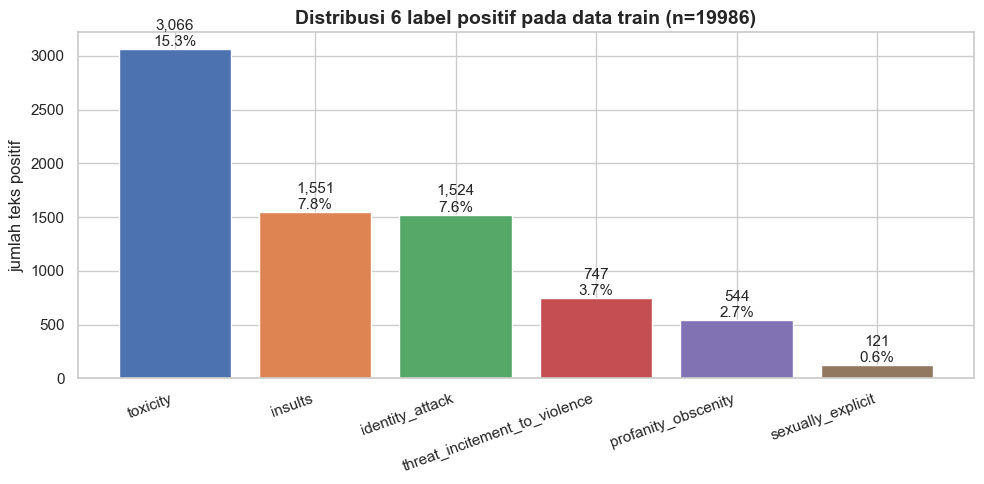

Perbandingan proporsi antar split (train vs val vs test):
                        label  train%  val%  test%
                     toxicity   15.34 16.03  15.83
          profanity_obscenity    2.72  4.26   4.25
threat_incitement_to_violence    3.74  3.78   3.80
                      insults    7.76  8.39   8.36
              identity_attack    7.63  7.85   7.80
            sexually_explicit    0.61  0.38   0.33


In [2]:
cnt = df[LABEL_COLS].sum().sort_values(ascending=False)
pct = cnt / len(df)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cnt.index, cnt.values, color=sns.color_palette('deep', len(cnt)))
for b, n, p in zip(bars, cnt.values, pct.values):
    teks_num = f'{int(n):,}'
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            teks_num + '\n{:.1%}'.format(p), ha='center', va='bottom', fontsize=11)
ax.set_title('Distribusi 6 label positif pada data train (n={})'.format(len(df)))
ax.set_ylabel('jumlah teks positif')
ax.set_xticklabels(cnt.index, rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_label_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Perbandingan proporsi antar split (train vs val vs test):')
rows = []
for c in LABEL_COLS:
    rows.append({'label': c,
                 'train%': round(df[c].mean() * 100, 2),
                 'val%': round(df_all[df_all.split == 'val'][c].mean() * 100, 2),
                 'test%': round(df_all[df_all.split == 'test'][c].mean() * 100, 2)})
print(pd.DataFrame(rows).to_string(index=False))

**Kesimpulan bagian 1 (bahan PPT):**

Dataset sangat timpang: toxicity paling banyak (sekitar 15%), sexually_explicit
paling langka (di bawah 1%). Ketimpangan ini wajar untuk data dunia nyata, tapi
konsekuensinya model bisa "curang" dengan selalu menjawab tidak untuk label
langka, sehingga akurasi saja menipu.

Poin yang bisa dijadikan bullet PPT:
- Rasio label terbanyak : terlangka sekitar 25 : 1 (toxicity 15,3% vs sexually_explicit 0,6%)
- Karena itu metrik utama kami macro-F1 (rata-rata F1 keenam label), bukan akurasi
- Proporsi antar split konsisten (tabel di atas), bukti split terstruktur dengan seimbang
- Label langka perlu class weight atau focal loss saat training

## 2. Panjang teks

Model Transformer butuh batas panjang input (max_length token). Histogram di
bawah menunjukkan panjang teks dalam jumlah kata; tampilan dipotong di 80 kata
agar wujudnya kebaca, karena ada beberapa teks sangat panjang. Panel kanan
membandingkan panjang teks toxic dan non-toxic secara berdampingan.

Statistik panjang teks (jumlah kata, train):
count    19986.0
mean        37.3
std         60.2
min          1.0
25%         11.0
50%         20.0
75%         36.0
max        880.0


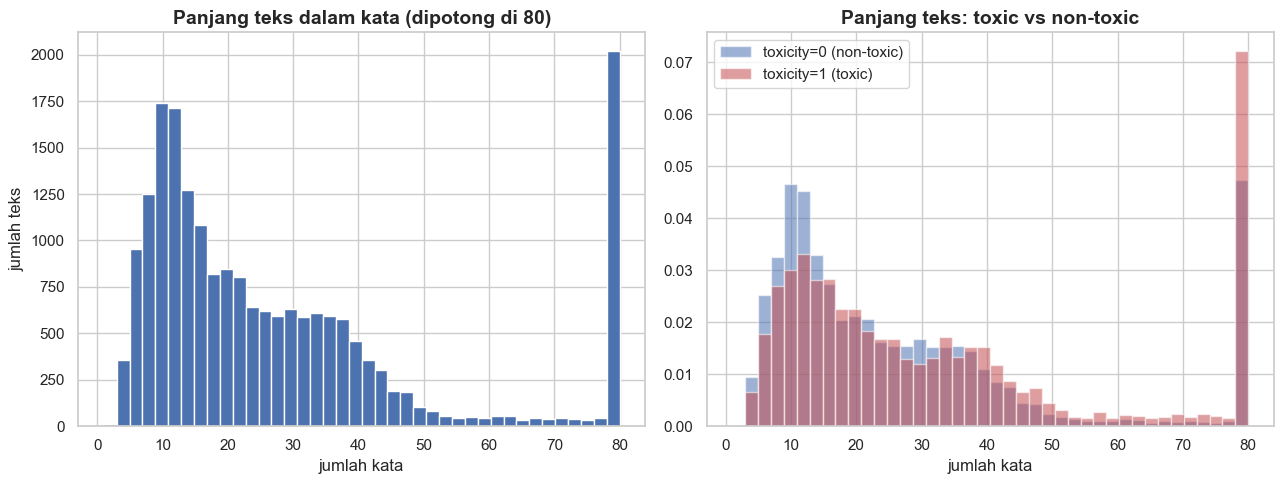

Rata-rata kata | toxic : 42.4 | non-toxic : 36.4
Persentil jumlah kata: p50=20 p90=80 p95=139 p99=302


In [3]:
df['n_word'] = df['text'].str.split().str.len()
df['n_char'] = df['text'].str.len()

print('Statistik panjang teks (jumlah kata, train):')
print(df['n_word'].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['n_word'].clip(0, 80), bins=40, color='#4c72b0')
axes[0].set_title('Panjang teks dalam kata (dipotong di 80)')
axes[0].set_xlabel('jumlah kata')
axes[0].set_ylabel('jumlah teks')

for y, c, nama in [(0, '#4c72b0', 'toxicity=0 (non-toxic)'), (1, '#c44e52', 'toxicity=1 (toxic)')]:
    axes[1].hist(df.loc[df.toxicity == y, 'n_word'].clip(0, 80), bins=40,
                 alpha=0.55, density=True, label=nama, color=c)
axes[1].set_title('Panjang teks: toxic vs non-toxic')
axes[1].set_xlabel('jumlah kata')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_text_length.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Rata-rata kata | toxic :', round(df.loc[df.toxicity == 1, 'n_word'].mean(), 1),
      '| non-toxic :', round(df.loc[df.toxicity == 0, 'n_word'].mean(), 1))
print('Persentil jumlah kata: p50={} p90={} p95={} p99={}'.format(
    int(df.n_word.quantile(0.5)), int(df.n_word.quantile(0.9)),
    int(df.n_word.quantile(0.95)), int(df.n_word.quantile(0.99))))

**Kesimpulan bagian 2 (bahan PPT):**

Mayoritas teks pendek: median 20 kata (setara 1-2 kalimat), tapi ekornya panjang
- p90 = 80 kata, p95 = 139, maks 880. Menariknya pada data final, teks toxic
rata-rata malah sedikit lebih panjang (42,4 kata) daripada non-toxic (36,4);
kemungkinan karena tie-break safety-first juga mengangkat sebagian teks ambigu
yang biasanya berbentuk uraian panjang.

Poin yang bisa dijadikan bullet PPT:
- Median 20 kata (teks sosmed pendek), p99 = 302 kata (pemaksaan ekor panjang)
- Toxic di data final justru sedikit lebih panjang, bukan lebih pendek
- Karena itu kami pilih max_length 256 token, supaya ~5% teks terpanjang tidak terpotong

## 3. Kata dan bigram paling sering: toxic vs non-toxic

Bagian ini bandingkan kosakata kedua kelompok setelah kata umum (stopword)
dibuang. Payu penting di sini: kalau kata toxic justru juga sering di teks aman,
berarti sinyalnya bukan di kamus kata, tapi di konteksnya - dan itu justru
membuktikan perlunya model pemahaman konteks (Transformer), bukan filter kata.

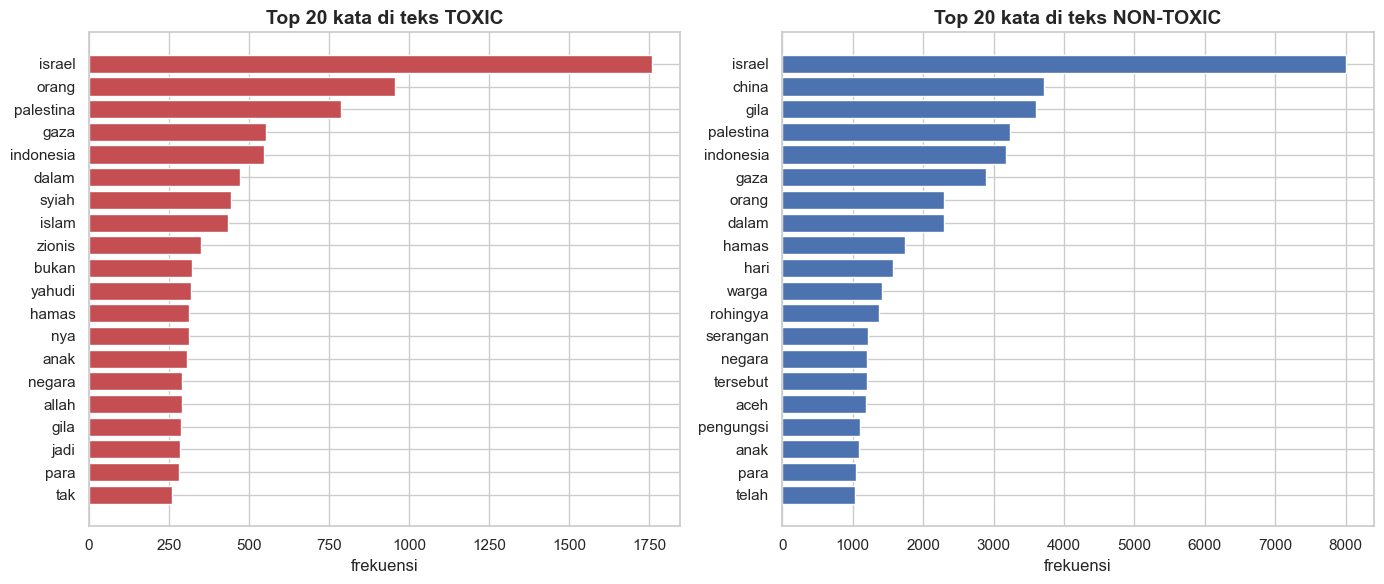

Top 10 bigram toxic    : ['orang orang', 'zionis israel', 'rumah sakit', 'jalur gaza', 'umat islam', 'anak anak', 'kaum muslimin', 'salah satu', 'warga sipil', 'cacat hukum']
Top 10 bigram non-toxic: ['pengungsi rohingya', 'rumah sakit', 'jalur gaza', 'israel palestina', 'warga palestina', 'salah satu', 'serangan israel', 'anak anak', 'selamat kepada', 'hasil pengeluaran']


In [4]:
STOP = set("""yang dan di ke dari ini itu dengan untuk tidak ya aku saya kamu dia mereka kita kami
ada adalah akan sudah belum juga hanya saja lebih oleh pada atau jika kalau karena tapi tetapi
bisa mau gue gua gw lo lu udah dah banget bgt sih dong deh kok nih tuh emang memang saat
sama apa kenapa gimana kaya kayak begini begitu gitu nggak ngga gak ga
the a in of and is it to you my me""".split())

def tokenize(s):
    return [w for w in re.findall(r"[a-zA-Z][a-zA-Z']+", s.lower())
            if w not in STOP and len(w) > 2]

uni_tox, uni_non = Counter(), Counter()
bi_tox, bi_non = Counter(), Counter()
for t, y in zip(df['text'], df['toxicity']):
    toks = tokenize(t)
    (uni_tox if y == 1 else uni_non).update(toks)
    (bi_tox if y == 1 else bi_non).update(zip(toks, toks[1:]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cnt, judul, warna in [(axes[0], uni_tox, 'Top 20 kata di teks TOXIC', '#c44e52'),
                              (axes[1], uni_non, 'Top 20 kata di teks NON-TOXIC', '#4c72b0')]:
    kata, nilai = zip(*cnt.most_common(20))
    pos = range(len(kata))[::-1]
    ax.barh(list(pos), list(nilai), color=warna)
    ax.set_yticks(list(pos))
    ax.set_yticklabels(kata, fontsize=11)
    ax.set_xlabel('frekuensi')
    ax.set_title(judul)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_top_unigrams.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 bigram toxic    :', [' '.join(b) for b, _ in bi_tox.most_common(10)])
print('Top 10 bigram non-toxic:', [' '.join(b) for b, _ in bi_non.most_common(10)])

**Kesimpulan bagian 3 (bahan PPT):**

Bigram toxic didominasi penyebutan identitas kelompok (misal "zionis israel",
"umat islam", "cacat hukum") - hate speech Indonesia lebih sering menyerang
lewat konteks identitas daripada kata kasar murni. Bukti lainnya: kata yang
SAMA muncul di kedua sisi (contoh "palestina", "gaza", "rumah sakit") -
topiknya sama, yang beda hanya nadanya.

Poin yang bisa dijadikan bullet PPT:
- Kata khas toxic = kata identitas kelompok, bukan kata Sumpong murni
- Kata yang sama muncul di teks toxic dan non-toxic -> filter kata tidak memadai
- Hate speech Indonesia banyak yang "halus tapi berbahaya" (profanity cuma ~3%,
  toxicity ~15%)
- Ini justifikasi pemakaian model kontekstual (IndoBERT/IndoBERTweet)

## 4. Co-occurrence antar label

Satu teks bisa punya beberapa label positif sekaligus. Heatmap di bawah menunjukkan
berapa teks yang menyatukan setiap pasangan label. Ini menentukan desain output
model: kalau label saling terkait kuat, arsitektur multi-label (6 sigmoid terpisah)
lebih cocok daripada 6 klasifikasi terpisah.

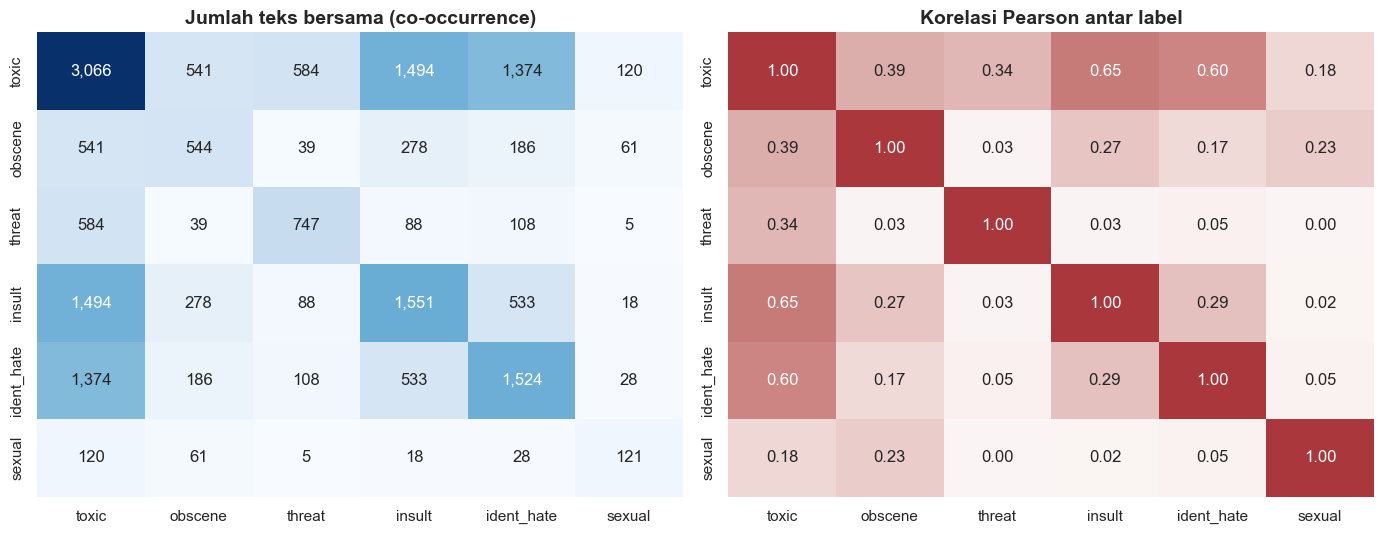

Teza dengan >=2 label sekaligus : 2983 from 19986 (14.9%)
Pairs co-occurrence terkuat:
   toxicity + insults : 1494 teks (korelasi 0.65)
   toxicity + identity_attack : 1374 teks (korelasi 0.60)
   toxicity + threat_incitement_to_violence : 584 teks (korelasi 0.34)


In [5]:
Y = df[LABEL_COLS].values
co = pd.DataFrame(Y.T @ Y, index=LABEL_COLS, columns=LABEL_COLS)
short = {'toxicity': 'toxic', 'profanity_obscenity': 'obscene',
         'threat_incitement_to_violence': 'threat', 'insults': 'insult',
         'identity_attack': 'ident_hate', 'sexually_explicit': 'sexual'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(co.rename(index=short, columns=short), annot=True, fmt=',d',
            cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Jumlah teks bersama (co-occurrence)')
corr = df[LABEL_COLS].rename(index=short, columns=short).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0,
            ax=axes[1], cbar=False)
axes[1].set_title('Korelasi Pearson antar label')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_label_cooccurrence.png'), dpi=150, bbox_inches='tight')
plt.show()

n_lab = df[LABEL_COLS].sum(axis=1)
print('Teza dengan >=2 label sekaligus :', int((n_lab >= 2).sum()),
      'from', len(df), '({:.1%})'.format((n_lab >= 2).mean()))
print('Pairs co-occurrence terkuat:')
pairs = [(i, j, int(co.iloc[i, j])) for i in range(6) for j in range(i + 1, 6)]
for i, j, v in sorted(pairs, key=lambda x: -x[2])[:3]:
    print('   {} + {} : {} teks (korelasi {:.2f})'.format(LABEL_COLS[i], LABEL_COLS[j], v, corr.iloc[i, j]))

**Kesimpulan bagian 4 (bahan PPT):**

Basis datanya memang multi-label, bukan klasifikasi satu jawaban. Sekitar 15%
teks punya dua label positif atau lebih, dan pasangan terkuat adalah
toxicity-insults dan toxicity-identity_attack - hinaan dan serangan identitas
hampir selalu mengiringi toxic.

Poin yang bisa dijadikan bullet PPT:
- 1 dari 7 teks punya 2 label positif atau lebih -> harus multi-label head (6 sigmoid)
- toxicity + insults korelasi paling kuat (r sekitar 0.65)
- Jadi arsitektur model: 6 output sigmoid per teks, bukan softmax 6 kelas

## 5. Fitur khas media sosial

Dataset ini berasal dari media sosial, jadi banyak fitur khas teks sosmed:
mention, hashtag, emoji, HURUF KAPITAL, dan huruf berulang (contoh: anii).
Bandurin persentasenya antara toxic dan non-toxic. Kalau fitur jelas terlihat
beda, itu argumen kuat untuk kualitas tokenizer IndoBERTweet yang dirancang
khusus menangani teks seperti ini.

C:\Users\User\AppData\Local\Temp\ipykernel_8960\3592033337.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_repeat'] = df['text'].str.contains(r'(.)\1{2,}', regex=True)


             seluruh train  toxicity=1  toxicity=0
has_mention            9.9        13.0         9.4
has_hashtag           25.8        20.3        26.8
has_url                1.7         2.0         1.7
has_emoji             21.4        22.5        21.2
has_allcaps           37.2        43.1        36.1
has_repeat            14.6        20.3        13.6


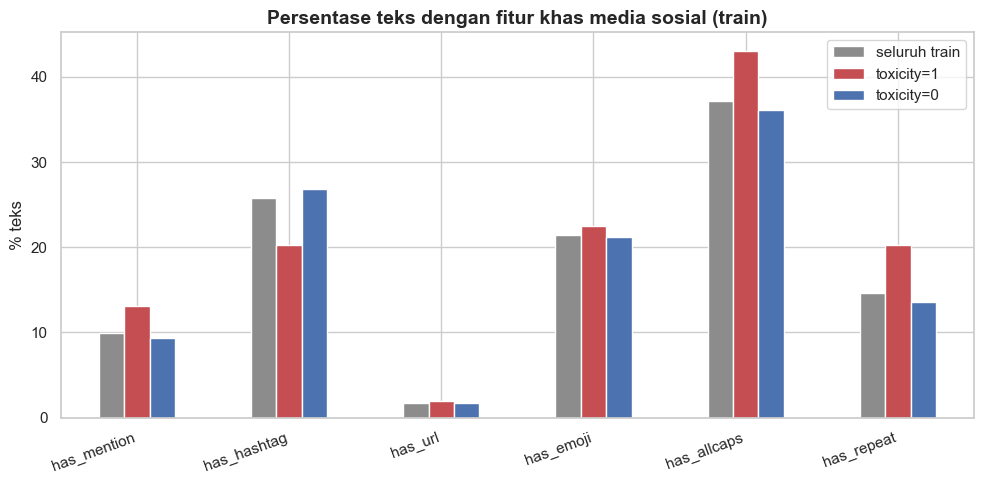

In [6]:
EMOJI_RE = re.compile(
    '[\U0001F000-\U0001FAFF\u2600-\u27BF\u2190-\u21FF\u2B00-\u2BFF\uFE00-\uFE0F]')

df['has_mention'] = df['text'].str.contains(r'@\w+', regex=True)
df['has_hashtag'] = df['text'].str.contains(r'#\w+', regex=True)
df['has_url'] = df['text'].str.contains(r'https?://\S+|www\.\S+', regex=True)
df['has_emoji'] = df['text'].str.contains(EMOJI_RE)
df['has_allcaps'] = df['text'].str.contains(r'\b[A-Z]{3,}\b', regex=True)
df['has_repeat'] = df['text'].str.contains(r'(.)\1{2,}', regex=True)

FEATS = ['has_mention', 'has_hashtag', 'has_url', 'has_emoji', 'has_allcaps', 'has_repeat']
share = pd.DataFrame({
    'seluruh train': df[FEATS].mean() * 100,
    'toxicity=1': df.groupby('toxicity')[FEATS].mean().loc[1] * 100,
    'toxicity=0': df.groupby('toxicity')[FEATS].mean().loc[0] * 100,
})
print(share.round(1).to_string())

ax = share.plot(kind='bar', figsize=(10, 5),
                color=['#8c8c8c', '#c44e52', '#4c72b0'])
plt.title('Persentase teks dengan fitur khas media sosial (train)')
plt.ylabel('% teks')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_social_features.png'), dpi=150, bbox_inches='tight')
plt.show()

**Kesimpulan bagian 5 (bahan PPT):**

Fitur khas sosmed sangat padat: huruf kapital dan hashtag muncul di sekitar
sepertiga teks, emoji di seperlima. Huruf berulang (contoh "aniiii") lebih sering
di teks toxic - jejak emosi saat mengetik. Hashtag sedikit menurun di teks toxic,
karena teks aman lebih banyak yang bergaya berita atau kampanye bertag.

Poin yang bisa dijadikan bullet PPT:
- Data ini benar-benar khas sosmed, bukan teks formal
- Sinyal gaya mengetik (huruf berulang, kapital) relevan untuk deteksi toxic
- Ini dasar hypothesis: IndoBERTweet (domain-adaptive sosmed) berpeluang unggul
  dibanding IndoBERT yang dilatih dari teks formal

## 6. Topik

Setiap teks diberi topik demografis saat data dikumpulkan (satu teks bisa
beberapa topik). Bagian ini menampilkan topik terbanyak dan rasio toxicity
per topik - topik dengan bar panjang punyaorsi toxic lebih tinggi dari yang lain.

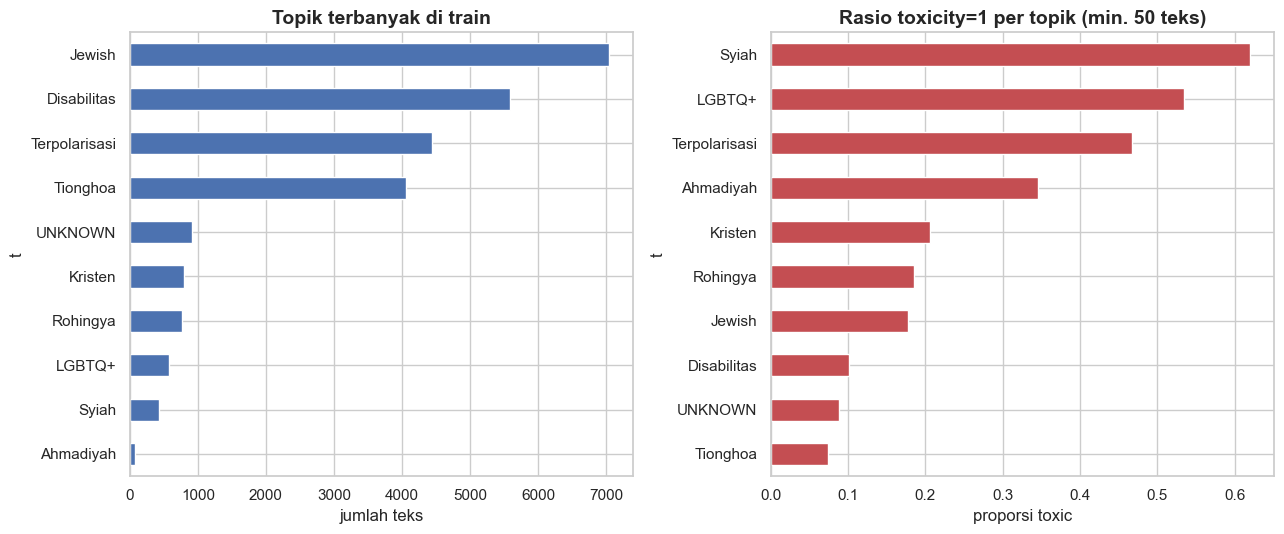

Jumlah topik unik : 10
Rata-rata topik per teks : 1.23

Rasio toxicity per topik (dari tinggi ke rendah):
t
Tionghoa          7.4
UNKNOWN           8.8
Disabilitas      10.1
Jewish           17.7
Rohingya         18.6
Kristen          20.7
Ahmadiyah        34.6
Terpolarisasi    46.7
LGBTQ+           53.4
Syiah            62.0


In [7]:
dft = df.assign(t=df['topic'].str.split(', ')).explode('t')
dft['t'] = dft['t'].str.strip()
cnt_topik = dft['t'].value_counts()
rate = dft.groupby('t')['toxicity'].agg(['mean', 'size']).query('size >= 50').sort_values('mean')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
cnt_topik.head(12)[::-1].plot(kind='barh', ax=axes[0], color='#4c72b0')
axes[0].set_title('Topik terbanyak di train')
axes[0].set_xlabel('jumlah teks')
rate['mean'].plot(kind='barh', ax=axes[1], color='#c44e52')
axes[1].set_title('Rasio toxicity=1 per topik (min. 50 teks)')
axes[1].set_xlabel('proporsi toxic')
for axi in axes:
    axi.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '08_topics.png'), dpi=150, bbox_inches='tight')
plt.show()

rata_topik_per_teks = df.topic.str.count(', ').add(1).mean()
print('Jumlah topik unik :', dft.t.nunique())
print('Rata-rata topik per teks :', round(rata_topik_per_teks, 2))
print()
print('Rasio toxicity per topik (dari tinggi ke rendah):')
print((rate['mean'] * 100).round(1).to_string())

**Kesimpulan bagian 6 (bahan PPT):**

Topik di dataset ini memang topik sensitif (Jewish, Terpolarisasi, Disabilitas,
Tionghoa, Rohingya, LGBTQ+, Syiah, Ahmadiyah) karena data dikumpulkan sengaja
dari percakasan seputar SARA dan isu panas. Rasio toxicnya tidak merata antar
topik - topik tertentu jauh lebih "panas" dari topik lain.

Poin yang bisa dijadikan bullet PPT:
- Topik sensitif memang ladang diskursus, tapi tingkat toxicitynya berbeda-beda
- Beberapa topik punya rasio toxic jauh di atas rata-rata global
- Hubungan topik-sensitivity ini penting saat interpretasi kesalahan model nanti

## 7. Sampel kualitatif per kategori

Cara cepat memahami label apa adanya: lihat teks jualannya. Untuk tiap kategori
saya tampilkan beberapa teks positif: yang annotation-nya penuh (agreement = 1)
dan yang ambigu (agreement di antara 0 dan 1, termasuk hasil tie-break safety-first).
Teks dipotong maksimal 95 karakter agar mudah dibaca. Ada juga dua grup kasus
menarik di bawah: (a) teks dengan kata kasar tapi TIDAK toxic, dan (b) teks toxic
TANPA kata kasar sama sekali - keduanya menunjukkan bahwa kamus kata tidak cukup.

In [8]:
def tampil(sub, judul, kolom_agr):
    if len(sub) == 0:
        print('  tidak ada contoh')
        return
    sampel = sub.sample(min(3, len(sub)), random_state=42)
    for _, r in sampel.iterrows():
        t = r['text'][:95] + ('...' if len(r['text']) > 95 else '')
        print('  [agr={:.2f} | n={}]'.format(r[kolom_agr], r['n_annotators']), repr(t))

for c in LABEL_COLS:
    kolom = 'agreement_' + c
    konsen = df[(df[c] == 1) & (df[kolom] == 1) & (df['text'].str.len() <= 100)]
    ambigu = df[(df[c] == 1) & (df[kolom] > 0) & (df[kolom] < 1) & (df['text'].str.len() <= 100)]
    print('===', c, '- contoh KONSENSUS (semua anotator setuju) ===')
    tampil(konsen, None, kolom)
    print('===', c, '- contoh AMBIGU (vote campuran / tie-break) ===')
    tampil(ambigu, None, kolom)
    print()

print('=== KASUS MENARIK (a): kata kasar TETAPI dinilai non-toxic (profanity=1, toxic=0) ===')
tampil(df[(df.profanity_obscenity == 1) & (df.toxicity == 0) & (df['text'].str.len() <= 90)],
       None, 'agreement_toxicity')
print()
print('=== KASUS MENARIK (b): toxic TANPA kata kasar sama sekali ===')
mb = df[(df.toxicity == 1) & (df.insults == 0) & (df.profanity_obscenity == 0) &
        (df.identity_attack == 0) & (df.threat_incitement_to_violence == 0) &
        (df['text'].str.len() <= 90)]
tampil(mb, None, 'agreement_toxicity')

=== toxicity - contoh KONSENSUS (semua anotator setuju) ===
  [agr=1.00 | n=1] '@IATeam____ Curiga Syiah main 2 kaki..'
  [agr=1.00 | n=1] 'Ketua HAM banyak bacot Bubarkan UNHCR dan HAM Kembalikan rohingya ke asalnya'
  [agr=1.00 | n=1] 'Wah gila sih, Bandung dimana2 bau sampah. Selain di depan rmh org, di TPS menggunung gila'
=== toxicity - contoh AMBIGU (vote campuran / tie-break) ===
  [agr=0.50 | n=2] 'bukan nak enabler LGBT tapi kalau selagi dia tak kacau hidup kau, kau boleh rilek x? takde keje...'
  [agr=0.69 | n=13] 'JOKOWI SIAPKAN PERANG MELAWAN RAKYAT MELAYU'
  [agr=0.50 | n=2] 'Pesan dan dukungan dari  hancurkan sistem2 dari zionis Israel'

=== profanity_obscenity - contoh KONSENSUS (semua anotator setuju) ===
  [agr=1.00 | n=2] 'macetnya jalur ahmad yani ke ujungberung jam 5sore bikin orang orang gila makin gila anjir'
  [agr=1.00 | n=1] 'Inpo angkringan e prei sek kae lo dulormu tulungi dijajah rohingya asu'
  [agr=1.00 | n=2] 'Astagfirullah rud4lnya di depan ambulans😭😭😭 b

**Kesimpulan bagian 7 (bahan PPT):**

Sampel kualitatif menunjukkan yang tidak taat kelihatan dari data mentah saja:
contoh konsensus adalah kasus mudah yang tanda-tandanya jelas; contoh ambigu ini
teks yang anotatornya tidak sepakat - label final-nya lahir dari aturan tie-break
safety-first. Grup kasus menarik (a) dan (b) membuktikan query bar kata tidak bisa
membedakan toxic/non-toxic: satu kelompok kata kasar tapi aman (ungkapan kaget),
kelompok lain menyerang tanpa satu kata kasar pun.

Poin yang bisa dijadikan bullet PPT:
- Contoh ambigu (~8% teks) kandidat utama error analysis saat evaluasi model
- Ada kata kasar yang dianggap aman (ekspresi emosi) -> stopword/filter kata tak diagnoses
- Ada hujatan tanpa kata kasar -> konteks menentukan, model harus paham kalimat utuh

## Kesimpulan EDA Konten (bahan PPT)

- Dataset sekitar 25 : 1, jadi metrik utama macro-F1 + class weight, bukan akurasi
- 15% teks multi-label (>= 2 label), toxicity-insults pasangan terkuat -> 6 sigmoid head
- Median 20 kata tapi ekor panjang -> max_length 256 token
- Kosakata toxic = identitas kelompok; kata yang sama muncul di kedua sisi -> butuh model kontekstual
- Fitur khas sosmed (emoji, kapital, huruf berulang) padat -> IndoBERTweet punya dasar keunggulan
- Sampel ambigu ditandai via agreement, jadi kelak bisa diisolasi saat error analysis

Semua gambar untuk PPT tersimpan di reports/figures/.